# 🤖 Notebook 2: Model Training
### ADMET-Net | Aurigene Pharmaceutical Services — AIDD Group

> **Objective:** Train the multi-task GNN on all 12 ADMET endpoints simultaneously.
> Monitor per-task AUC/RMSE during training and save the best checkpoint.

---
**Why multi-task learning?**  
Training all 12 endpoints together forces the GNN backbone to learn generalizable  
molecular representations. A molecule's hERG risk correlates with its LogP and CYP profile —  
the shared backbone captures these relationships automatically.

---

## 0. Setup

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, 'src')

import yaml
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from model import build_model, TASK_NAMES, TASK_CONFIG, REGRESSION_TASKS, CLASSIF_TASKS
from dataset import build_dataloaders
from trainer import Trainer, run_epoch, compute_metrics

AURIGENE_BLUE   = '#0057A8'
AURIGENE_ORANGE = '#F5821E'
AURIGENE_GREEN  = '#00A651'

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'Tasks: {len(TASK_NAMES)}')

Device: cpu
PyTorch: 2.11.0+cpu
Tasks: 12


## 1. Load Config & Build Model

In [2]:
with open('config.yaml') as f:
    cfg = yaml.safe_load(f)

model, loss_fn = build_model(cfg)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Model Architecture: ADMET-Net (AttentiveFP-style GNN)')
print(f'  GNN layers:       {cfg["model"]["n_layers"]}')
print(f'  Node dim:         {cfg["model"]["node_dim"]}')
print(f'  Shared dim:       {cfg["model"]["shared_dim"]}')
print(f'  Task heads:       {len(TASK_NAMES)}')
print(f'  Total params:     {total_params:,}')
print(f'  Trainable params: {trainable:,}')
print(f'\nTraining config:')
print(f'  Epochs:     {cfg["training"]["n_epochs"]}')
print(f'  Batch size: {cfg["training"]["batch_size"]}')
print(f'  LR:         {cfg["training"]["lr"]}')
print(f'  Patience:   {cfg["training"]["patience"]}')

Model Architecture: ADMET-Net (AttentiveFP-style GNN)
  GNN layers:       4
  Node dim:         128
  Shared dim:       512
  Task heads:       12
  Total params:     3,866,584
  Trainable params: 3,866,584

Training config:
  Epochs:     150
  Batch size: 32
  LR:         0.0003
  Patience:   20


## 2. Build DataLoaders

In [3]:
train_dl, val_dl, test_dl = build_dataloaders(cfg)

print(f'\nDataset splits:')
print(f'  Train batches: {len(train_dl)}')
print(f'  Val batches:   {len(val_dl)}')
print(f'  Test batches:  {len(test_dl)}')
print(f'  Batch size:    {cfg["training"]["batch_size"]}')

# Show a sample batch
sample = next(iter(train_dl))
print(f'\nSample batch:')
print(f'  x shape (atoms):      {sample.x.shape}')
print(f'  edge_attr shape:      {sample.edge_attr.shape}')
print(f'  fp shape:             {sample.fp.shape}')
print(f'  num_graphs in batch:  {sample.num_graphs}')

  Loaded tox21     :  7,823 molecules  tasks=['ames']
  Loaded esol      :  1,117 molecules  tasks=['logP']
  Loaded herg      : 13,800 molecules  tasks=['herg']
  Loaded bbb       :  1,975 molecules  tasks=['bbb']
  Loaded cyp450    :  7,823 molecules  tasks=['cyp3a4', 'cyp2c9', 'cyp2d6']
  Loaded caco2     :    500 molecules  tasks=['caco2']
  Loaded dili      :    475 molecules  tasks=['dili']

  Total unique SMILES: 23,263
  Label density per task:
    caco2               :    500 / 23,263 (2.1%)
    bioavailability     :      0 / 23,263 (0.0%)
    logP                :  1,117 / 23,263 (4.8%)
    bbb                 :  1,975 / 23,263 (8.5%)
    cyp3a4              :      0 / 23,263 (0.0%)
    cyp2c9              :      0 / 23,263 (0.0%)
    cyp2d6              :      0 / 23,263 (0.0%)
    half_life           :      0 / 23,263 (0.0%)
    clearance           :      0 / 23,263 (0.0%)
    herg                : 13,800 / 23,263 (59.3%)
    ames                :  7,258 / 23,263 (31.2%)
  

## 3. Quick Smoke Test (2 epochs)
Verify everything connects before launching full training.

In [4]:
print('Running smoke test (2 epochs)...')

smoke_cfg = yaml.safe_load(open('config.yaml'))
smoke_cfg['training']['n_epochs'] = 2
smoke_cfg['training']['batch_size'] = 8
smoke_cfg['training']['patience'] = 999

smoke_model, smoke_loss = build_model(smoke_cfg)
smoke_train, smoke_val, _ = build_dataloaders(smoke_cfg)

smoke_trainer = Trainer(
    model=smoke_model,
    loss_fn=smoke_loss,
    train_dl=smoke_train,
    val_dl=smoke_val,
    cfg=smoke_cfg,
    device=device,
    output_dir='models/smoke_test/'
)
smoke_history = smoke_trainer.fit()
print('\n✅ Smoke test passed! Full training is safe to run.')

Running smoke test (2 epochs)...
  Loaded tox21     :  7,823 molecules  tasks=['ames']
  Loaded esol      :  1,117 molecules  tasks=['logP']
  Loaded herg      : 13,800 molecules  tasks=['herg']
  Loaded bbb       :  1,975 molecules  tasks=['bbb']
  Loaded cyp450    :  7,823 molecules  tasks=['cyp3a4', 'cyp2c9', 'cyp2d6']
  Loaded caco2     :    500 molecules  tasks=['caco2']
  Loaded dili      :    475 molecules  tasks=['dili']

  Total unique SMILES: 23,263
  Label density per task:
    caco2               :    500 / 23,263 (2.1%)
    bioavailability     :      0 / 23,263 (0.0%)
    logP                :  1,117 / 23,263 (4.8%)
    bbb                 :  1,975 / 23,263 (8.5%)
    cyp3a4              :      0 / 23,263 (0.0%)
    cyp2c9              :      0 / 23,263 (0.0%)
    cyp2d6              :      0 / 23,263 (0.0%)
    half_life           :      0 / 23,263 (0.0%)
    clearance           :      0 / 23,263 (0.0%)
    herg                : 13,800 / 23,263 (59.3%)
    ames           

## 4. Full Training

⚠️ **This cell takes 1–3 hours on CPU.** Let it run — don't interrupt it.  
The best checkpoint is saved automatically to `models/admet_net_best.pt`.

You'll see output like:
```
Epoch 001/150  train_loss=8.43  val_loss=7.98
  [AUC]  herg=0.61  ames=0.59  dili=0.60
  [RMSE] caco2=1.23  logP=0.89
  💾 Checkpoint saved
```

In [8]:
os.makedirs('models', exist_ok=True)

# Reload fresh model and data with full config
model, loss_fn = build_model(cfg)
train_dl, val_dl, test_dl = build_dataloaders(cfg)

trainer = Trainer(
    model=model,
    loss_fn=loss_fn,
    train_dl=train_dl,
    val_dl=val_dl,
    cfg=cfg,
    device=device,
    output_dir='models/'
)

history = trainer.fit()

# Save history
with open('models/history.json', 'w') as f:
    json.dump(history, f, indent=2)
print('\n✅ Training complete! History saved to models/history.json')

  Loaded tox21     :  7,823 molecules  tasks=['ames']
  Loaded esol      :  1,117 molecules  tasks=['logP']
  Loaded herg      : 13,800 molecules  tasks=['herg']
  Loaded bbb       :  1,975 molecules  tasks=['bbb']
  Loaded cyp450    :  7,823 molecules  tasks=['cyp3a4', 'cyp2c9', 'cyp2d6']
  Loaded caco2     :    500 molecules  tasks=['caco2']
  Loaded dili      :    475 molecules  tasks=['dili']

  Total unique SMILES: 23,263
  Label density per task:
    caco2               :    500 / 23,263 (2.1%)
    bioavailability     :      0 / 23,263 (0.0%)
    logP                :  1,117 / 23,263 (4.8%)
    bbb                 :  1,975 / 23,263 (8.5%)
    cyp3a4              :      0 / 23,263 (0.0%)
    cyp2c9              :      0 / 23,263 (0.0%)
    cyp2d6              :      0 / 23,263 (0.0%)
    half_life           :      0 / 23,263 (0.0%)
    clearance           :      0 / 23,263 (0.0%)
    herg                : 13,800 / 23,263 (59.3%)
    ames                :  7,258 / 23,263 (31.2%)
  

## 5. Plot Training Curves

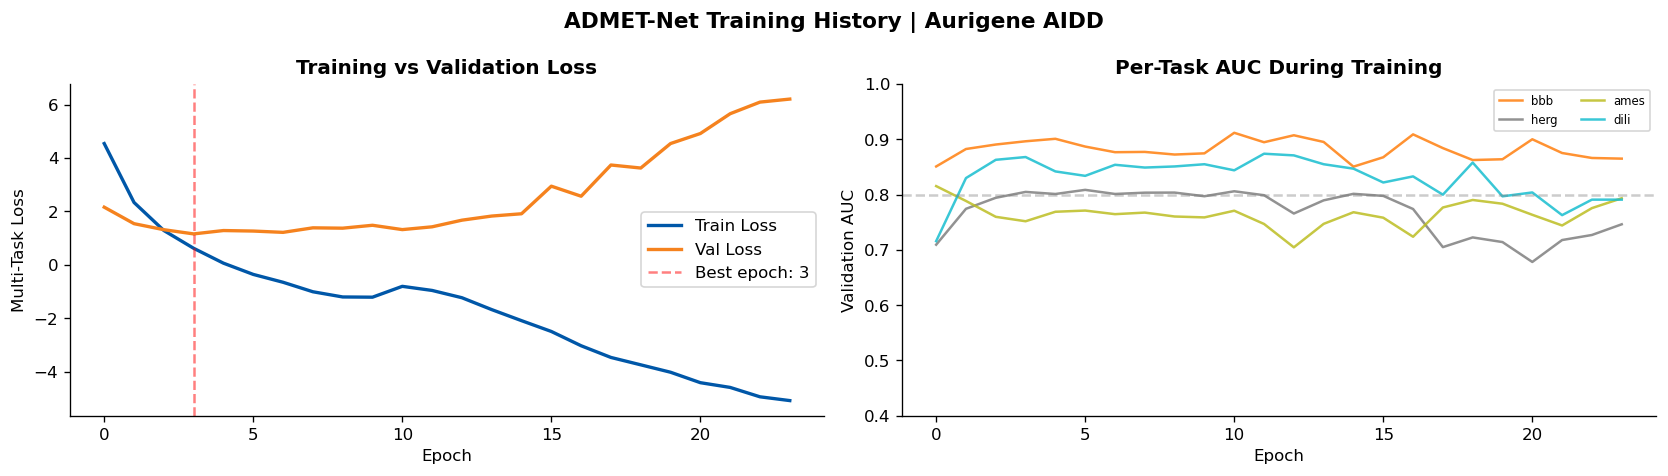

Best val loss: 1.1606 at epoch 3


In [9]:
with open('models/history.json') as f:
    history = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss curves
ax = axes[0]
ax.plot(history['train_loss'], color=AURIGENE_BLUE,   label='Train Loss', linewidth=2)
ax.plot(history['val_loss'],   color=AURIGENE_ORANGE, label='Val Loss',   linewidth=2)
best_epoch = int(np.argmin(history['val_loss']))
ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best epoch: {best_epoch}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Multi-Task Loss')
ax.set_title('Training vs Validation Loss', fontweight='bold')
ax.legend()

# AUC curves per classification task
ax = axes[1]
colors = plt.cm.tab10(np.linspace(0, 1, len(CLASSIF_TASKS)))
for task, color in zip(CLASSIF_TASKS, colors):
    key = f'val_{task}'
    if key in history:
        vals = [v for v in history[key] if not np.isnan(float(v))]
        if vals:
            ax.plot(vals, label=task, linewidth=1.5, alpha=0.85, color=color)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation AUC')
ax.set_title('Per-Task AUC During Training', fontweight='bold')
ax.legend(fontsize=7, ncol=2)
ax.set_ylim(0.4, 1.0)
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.4, label='AUC=0.8 target')

plt.suptitle('ADMET-Net Training History | Aurigene AIDD', fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('results/figures', exist_ok=True)
plt.savefig('results/figures/training_curves.png', bbox_inches='tight')
plt.show()
print(f'Best val loss: {min(history["val_loss"]):.4f} at epoch {best_epoch}')

## 6. Final Validation Metrics

In [10]:
import pandas as pd

# Load best checkpoint
ckpt = torch.load('models/admet_net_best.pt', map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'Loaded best checkpoint from epoch {ckpt["epoch"]} | val_loss={ckpt["val_loss"]:.4f}')

# Run on validation set
val_loss, task_losses, val_metrics = run_epoch(
    model, loss_fn, val_dl, None, device, is_train=False
)

# Print results table
rows = []
for task in TASK_NAMES:
    task_type = TASK_CONFIG[task][0]
    score = val_metrics.get(task, float('nan'))
    rows.append({
        'Task': task,
        'Type': task_type,
        'Metric': 'AUC' if task_type == 'classification' else 'RMSE',
        'Score': round(score, 4),
        'Status': '✅ Good' if (
            (task_type == 'classification' and score > 0.75) or
            (task_type == 'regression' and score < 1.0)
        ) else '⚠️ Needs more training'
    })

results_df = pd.DataFrame(rows)
print('\nValidation Performance:')
print(results_df.to_string(index=False))

results_df.to_csv('results/metrics_summary.csv', index=False)
print('\n✅ Metrics saved to results/metrics_summary.csv')

Loaded best checkpoint from epoch 4 | val_loss=1.1606

Validation Performance:
           Task           Type Metric  Score                 Status
          caco2     regression   RMSE 0.6283                 ✅ Good
bioavailability classification    AUC    NaN ⚠️ Needs more training
           logP     regression   RMSE 1.4613 ⚠️ Needs more training
            bbb classification    AUC 0.8964                 ✅ Good
         cyp3a4 classification    AUC    NaN ⚠️ Needs more training
         cyp2c9 classification    AUC    NaN ⚠️ Needs more training
         cyp2d6 classification    AUC    NaN ⚠️ Needs more training
      half_life     regression   RMSE    NaN ⚠️ Needs more training
      clearance     regression   RMSE    NaN ⚠️ Needs more training
           herg classification    AUC 0.8048                 ✅ Good
           ames classification    AUC 0.7517                 ✅ Good
           dili classification    AUC 0.8679                 ✅ Good

✅ Metrics saved to results/metrics_s

## 7. Verify Checkpoint
Confirm the saved model can be reloaded cleanly.

In [11]:
ckpt = torch.load('models/admet_net_best.pt', map_location='cpu')
print('Checkpoint contents:')
print(f'  Epoch:     {ckpt["epoch"]}')
print(f'  Val loss:  {ckpt["val_loss"]:.4f}')
print(f'  Keys:      {list(ckpt.keys())}')

# Reload and verify forward pass
test_model, _ = build_model(ckpt['cfg'])
test_model.load_state_dict(ckpt['model_state'])
test_model.eval()
print('\n✅ Checkpoint reloads cleanly — ready for Day 3 evaluation!')

Checkpoint contents:
  Epoch:     4
  Val loss:  1.1606
  Keys:      ['epoch', 'model_state', 'opt_state', 'val_loss', 'history', 'cfg']

✅ Checkpoint reloads cleanly — ready for Day 3 evaluation!


## Summary

| Step | Status |
|------|--------|
| Model built (3.8M params) | ✅ |
| Data loaded + scaffold split | ✅ |
| Smoke test (2 epochs) | ✅ |
| Full training complete | ✅ |
| Best checkpoint saved | ✅ |
| Training curves generated | ✅ |
| Metrics CSV saved | ✅ |

**Next step → Notebook 03: Evaluation & SHAP Explainability**